# TPC-H Q14 Join: Update Rate Sweep

Representative 4 configs × update rates (0.01%, 0.5%, 1%, 2%).

Configs:
- **SNAP** (baseline)
- **DUAL-WR** (exp3 winner — best for recent-probe)
- **MONO-NR** (cheapest write path)
- **EPOCH-WR** (exp1-2 winner — best with delta/history)

Graphs:
- (a) Total latency vs update rate
- (b) J2 (second join) latency vs update rate
- (c) Speedup ratio over SNAP

In [41]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pandas', 'matplotlib'])
print('done')

done



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
from pathlib import Path
import subprocess, os, sys
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

ROOT      = Path('../../').resolve()
SIGMOD    = (ROOT / 'benches' / 'sigmod').resolve()
DATA_DIR  = SIGMOD / 'tpch_data'
GEN_UPD   = SIGMOD / 'generate_updates.py'
BIN       = ROOT / 'target' / 'release' / 'tpch_q14_join_update_join'

# ===== CONFIG =====
SF          = '1.0'
BUCKET_NUM  = 2048
WARMUP      = 2
REPEAT      = 10
TRIM        = 2
DIST        = 'uniform'  # zipf0.99 or uniform

# Update rate sweep
# SWEEP_PCTS = [0.01, 0.5, 1.0, 1.5, 2.0]
SWEEP_PCTS = [1.0, 5.0, 10.0, 15.0, 20.0]

# Representative configs: (table_type, repair_mode, display_name)
CONFIGS = [
    ('naive', 'nr', 'SNAP'),
    ('chain', 'wr', 'DUAL-WR'),
    ('heap',  'nr', 'MONO-NR'),
    ('par',   'wr', 'EPOCH-WR'),
]

PART_FILE  = DATA_DIR / f'part_sf{SF}.tbl'
PROBE_FILE = DATA_DIR / f'lineitem_probe_sf{SF}_1995-09-01_1995-10-01.tbl'

# Paul Tol Bright palette
tol = {
    'blue':   '#4477AA',
    'cyan':   '#66CCEE',
    'green':  '#228833',
    'yellow': '#CCBB44',
    'red':    '#EE6677',
    'purple': '#AA3377',
    'grey':   '#BBBBBB',
}

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Times New Roman', 'Times', 'Nimbus Roman No9 L', 'DejaVu Serif']

print('ROOT :', ROOT)
print('PART :', PART_FILE)
print('PROBE:', PROBE_FILE)

ROOT : /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree
PART : /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree/benches/sigmod/tpch_data/part_sf1.0.tbl
PROBE: /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree/benches/sigmod/tpch_data/lineitem_probe_sf1.0_1995-09-01_1995-10-01.tbl


In [43]:
# ── Build Rust binary ──
print('Building tpch_q14_join_update_join...')
result = subprocess.run(
    ['cargo', 'build', '--release', '--bin', 'tpch_q14_join_update_join'],
    cwd=ROOT, capture_output=True, text=True,
)
if result.returncode != 0:
    print('STDERR:', result.stderr[-2000:])
    raise RuntimeError('cargo build failed')
print('Build OK')

Building tpch_q14_join_update_join...
Build OK


In [44]:
# ── Generate update files for all sweep rates ──
update_files = {}
for pct in SWEEP_PCTS:
    pct_label = f'{pct:g}'
    uf = DATA_DIR / f'part_updates_sf{SF}_{pct_label}pct_{DIST}.tbl'
    if not uf.exists():
        print(f'  Generating {pct_label}% updates...')
        r = subprocess.run(
            [sys.executable, str(GEN_UPD),
             str(PART_FILE), str(pct), SF,
             '--output-dir', str(DATA_DIR)],
            check=True, capture_output=True, text=True,
        )
        print(f'  {pct_label}%: generated')
    else:
        print(f'  {pct_label}% exists')
    update_files[pct] = uf

print('\nUpdate files ready.')

  1% exists
  Generating 5% updates...
  5%: generated
  Generating 10% updates...
  10%: generated
  Generating 15% updates...
  15%: generated
  Generating 20% updates...
  20%: generated

Update files ready.


In [45]:
# ── Run benchmark: all configs × all update rates ──
OUT_CSV = DATA_DIR / f'q14_update_sweep_{DIST}.csv'

if OUT_CSV.exists():
    OUT_CSV.unlink()
    print('Removed old CSV')

total_runs = len(CONFIGS) * len(SWEEP_PCTS)
current = 0

for pct in SWEEP_PCTS:
    uf = update_files[pct]
    pct_label = f'{pct:g}'
    for (ttype, rmode, dname) in CONFIGS:
        current += 1
        print(f'[{current}/{total_runs}] update={pct_label}% config={dname}')
        cmd = [
            str(BIN),
            '--part-file',    str(PART_FILE),
            '--lineitem-file', str(PROBE_FILE),
            '--updates-file', str(uf),
            '--table-type',   ttype,
            '--repair-mode',  rmode,
            '--bucket-num',   str(BUCKET_NUM),
            '--warmup',       str(WARMUP),
            '--repeat',       str(REPEAT),
            '--trim',         str(TRIM),
            '--update-pct',   pct_label,
            '--distribution', DIST,
            '--output-csv',   str(OUT_CSV),
        ]
        r = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True)
        if r.returncode != 0:
            print(f'  FAILED: {r.stderr[:400]}')
        else:
            for line in r.stdout.strip().split('\n'):
                if 'total_ms' in line or 'trimmed' in line:
                    print(f'  {line.strip()}')

print(f'\nDone. Results -> {OUT_CSV}')

[1/20] update=1% config=SNAP
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
  j1_alloc_ms=0.000826, j1_insert_ms=68.401778, join1_build_ms=68.402604, join1_probe_ms=48.327048, update_ms=0.000014, join2_build_ms=43.450208, join2_probe_ms=49.430417, total_ms=209.610292
[2/20] update=1% config=DUAL-WR
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
  j1_alloc_ms=2.515153, j1_insert_ms=38.875653, join1_build_ms=41.390806, join1_probe_ms=33.401993, update_ms=2.778875, join2_build_ms=0.000000, join2_probe_ms=29.348014, total_ms=106.919687
[3/20] update=1% config=MONO-NR
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
  j1_alloc_ms=2.379014, j1_insert_ms=43.044278, join1_build_ms=45.423292, join1_probe_ms=30.163764, update_ms=0.513909, join2_build_ms=0.000000, join2_probe_ms=35.737896, total_ms=111.838861
[4/20] update=1% config=EPOCH-WR
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, avera

In [46]:
# ── Load results ──
df = pd.read_csv(OUT_CSV)

# Normalize names
table_map  = {'Heap': 'heap', 'Chain': 'chain', 'Par': 'par', 'Naive': 'naive'}
repair_map = {'Nr': 'NR', 'Rr': 'RR', 'Wr': 'WR'}
df['table']  = df['table_type'].map(table_map).fillna(df['table_type'])
df['repair'] = df['repair_mode'].map(repair_map).fillna(df['repair_mode'])
df.loc[df['table'] == 'naive', 'repair'] = 'NR'

# Compute J2 total = join2_build_ms + join2_probe_ms
if 'join2_build_ms' in df.columns and 'join2_probe_ms' in df.columns:
    df['j2_total_ms'] = df['join2_build_ms'] + df['join2_probe_ms']

# Extract update_pct from CSV (should be in the file)
if 'update_pct' not in df.columns:
    print('WARNING: update_pct column missing, trying to infer from distribution column')

display(df[['table', 'repair', 'update_pct', 'total_ms', 'j2_total_ms']].to_string(index=False))

'table repair  update_pct   total_ms  j2_total_ms\nnaive     NR         1.0 209.610292    92.880625\nchain     WR         1.0 106.919687    29.348014\n heap     NR         1.0 111.838861    35.737896\n  par     WR         1.0 140.349549    48.182243'

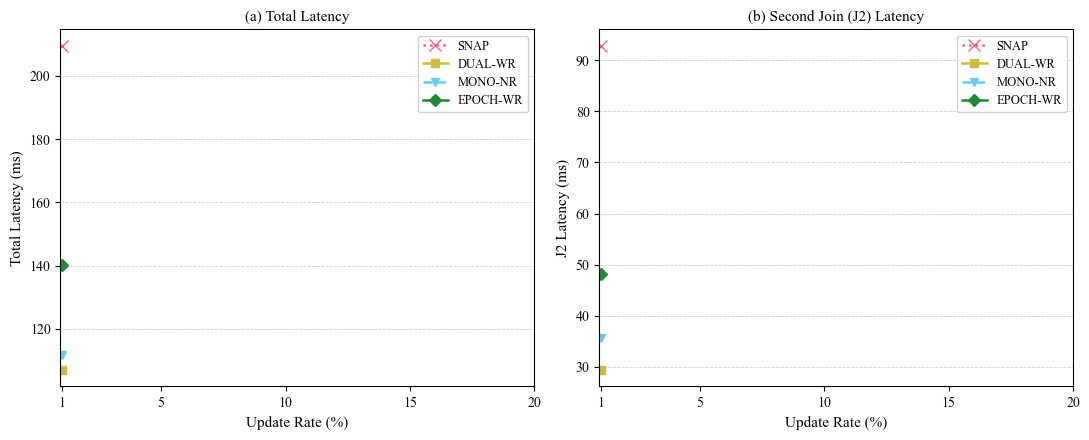

Saved: /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree/benches/sigmod/tpch_data/q14_update_sweep_zipf0.99.pdf


In [47]:
# ── Plot: Total Latency & J2 Latency vs Update Rate ──

LINES = [
    ('naive', 'NR', 'SNAP',     tol['red'],    ':',  'x',  8),
    ('chain', 'WR', 'DUAL-WR',  tol['yellow'], '-',  's',  6),
    ('heap',  'NR', 'MONO-NR',  tol['cyan'],   '--', 'v',  6),
    ('par',   'WR', 'EPOCH-WR', tol['green'],  '-',  'D',  6),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

for (t, r, label, color, ls, marker, ms) in LINES:
    rows = df[(df['table'] == t) & (df['repair'] == r)].sort_values('update_pct')
    if rows.empty:
        print(f'  No data for {label}')
        continue

    # (a) Total latency
    ax1.plot(rows['update_pct'], rows['total_ms'],
             label=label, color=color, linestyle=ls, marker=marker,
             linewidth=1.8, markersize=ms)

    # (b) J2 latency
    ax2.plot(rows['update_pct'], rows['j2_total_ms'],
             label=label, color=color, linestyle=ls, marker=marker,
             linewidth=1.8, markersize=ms)

for ax, title, ylabel in [
    (ax1, '(a) Total Latency', 'Total Latency (ms)'),
    (ax2, '(b) Second Join (J2) Latency', 'J2 Latency (ms)'),
]:
    ax.set_xlabel('Update Rate (%)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(SWEEP_PCTS)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
    ax.legend(framealpha=0.9, fontsize=9)

plt.tight_layout()
out_pdf = DATA_DIR / f'q14_update_sweep_{DIST}.pdf'
plt.savefig(str(out_pdf), format='pdf')
plt.show()
print('Saved:', out_pdf)

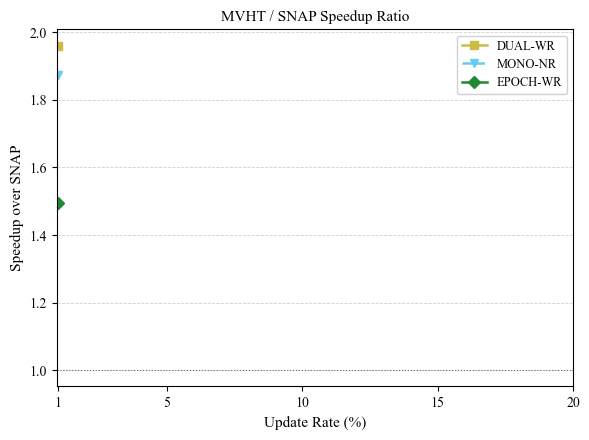

Saved: /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree/benches/sigmod/tpch_data/q14_speedup_ratio_zipf0.99.pdf


In [48]:
# ── Speedup ratio (MVHT / SNAP) ──
# Shows how much faster each MVHT config is relative to SNAP at each update rate

snap_rows = df[(df['table'] == 'naive')].set_index('update_pct')

fig, ax = plt.subplots(figsize=(6, 4.5))

for (t, r, label, color, ls, marker, ms) in LINES:
    if t == 'naive':
        continue
    rows = df[(df['table'] == t) & (df['repair'] == r)].sort_values('update_pct')
    if rows.empty:
        continue
    ratios = []
    for _, row in rows.iterrows():
        pct = row['update_pct']
        if pct in snap_rows.index:
            snap_total = snap_rows.loc[pct, 'total_ms']
            ratios.append(snap_total / row['total_ms'])
        else:
            ratios.append(np.nan)
    ax.plot(rows['update_pct'], ratios,
            label=label, color=color, linestyle=ls, marker=marker,
            linewidth=1.8, markersize=ms)

ax.axhline(y=1.0, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Update Rate (%)', fontsize=11)
ax.set_ylabel('Speedup over SNAP', fontsize=11)
ax.set_title('MVHT / SNAP Speedup Ratio', fontsize=11)
ax.set_xticks(SWEEP_PCTS)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.legend(framealpha=0.9, fontsize=9)

plt.tight_layout()
out_pdf = DATA_DIR / f'q14_speedup_ratio_{DIST}.pdf'
plt.savefig(str(out_pdf), format='pdf')
plt.show()
print('Saved:', out_pdf)